In [2]:
from datetime import datetime, timedelta
import uo_pyfetch
import calendar
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import requests
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from pyproj import Transformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error


In [3]:
bbox = [-1.652756, 54.973377, -1.620483, 54.983721]

In [4]:
variables = uo_pyfetch.get_variables()
print("Available variables:")
for v in variables["Variables"][:1000]:
    print(f" - {v['Name']} ({v.get('Units', 'no units')})")

Available variables:
 - allpollu (%)
 - Ammonia (?)
 - Average Speed (KmPH)
 - Battery (V)
 - Brood (Celsius)
 - Bus Count (Vehicles)
 - Bus Count East (Vehicles)
 - Bus Count West (Vehicles)
 - Car Count (Vehicles)
 - Cars (Cars)
 - CO (ugm -3)
 - CO2 (ppm)
 - CO2 High Range (ppm)
 - CO2 Low Range (ppm)
 - Congestion (%)
 - Cycle Count (Vehicles)
 - Daily Accumulation Rainfall (mm)
 - Depth (m)
 - Dew Point (Celsius)
 - Dissolved Oxygen (mg/l)
 - Dissolved Oxygen Percentage (%)
 - Dust (?)
 - East-West Horizontal Displacement (m)
 - Filter (%)
 - Fluorescent Dissolved Organic Matter (QSU)
 - Hive Activity (-)
 - Humidity (%)
 - Internal Humidity (%)
 - Internal Temperature (Celsius)
 - Journey Time (seconds)
 - Luminosity (Lux)
 - Max Sound (db)
 - Max Temperature  (Celsius)
 - Max Wind Speed (m/s)
 - Mean Fanning (-)
 - Mean Flight Noise (-)
 - Moisture (%)
 - Motorcycle Count (Vehicles)
 - NH4+N (mg/l)
 - NO (ugm -3)
 - NO2 (ugm -3)
 - NO2 Concentration (ugm -3)
 - NO3-N (mg/l)
 - N

In [5]:
themes = uo_pyfetch.get_themes()
print("\nAvailable themes:")
for t in themes["Themes"]:
    print(f" - {t['Name']}")


Available themes:
 - Sewage
 - Sensor Metrics
 - Electrical
 - Seismic
 - Water Quality
 - Traffic
 - Air Quality
 - Water Level
 - Bee Hive
 - People
 - Building
 - Environment
 - Weather
 - Noise
 - Vehicles


In [6]:
print("\nFetching sensors in bbox...")
sensors_df = uo_pyfetch.get_sensors() #bondary box


Fetching sensors in bbox...


In [7]:
#amount of sensors
print(sensors_df.drop_duplicates().count())

Sensor_Name                      1000
Location_WKT                     1000
Sensor_Centroid_Longitude        1000
Ground_Height_Above_Sea_Level    1000
Sensor_Centroid_Latitude         1000
Sensor_Height_Above_Ground       1000
Broker_Name                      1000
Raw_ID                           1000
dtype: int64


In [8]:
#variables for congestion
variables = [   
    
"NO2",
"Temperature",
"Particle Count",
"O3",
"PM 4",
"PM2.5",
"PM10",
"PM1",
"NO",
"Humidity",
"Plates Out",
"Plates In",
"Plates Matching",
"Journey Time",
"Temperature",
"Humidity", 
"Pressure"
]

In [9]:
n = 100
print("\nFetching sensor data (last n days)...")
sensor_data_df = uo_pyfetch.get_sensor_data(
    last_n_hours=n*24,
    variables=variables,
    bbox=bbox,
    limit=10000000
)


Fetching sensor data (last n days)...


In [10]:
print(sensor_data_df["Variable"].drop_duplicates())

0        Journey Time
1           Plates In
2          Plates Out
3     Plates Matching
4            Pressure
5            Humidity
6                  O3
7                  NO
8                 NO2
9                 PM1
10               PM10
15               PM 4
16              PM2.5
17     Particle Count
18        Temperature
Name: Variable, dtype: object


In [11]:
print("Data shape:", sensor_data_df.shape)
print("Columns:", sensor_data_df.columns)
print("Missing values per column:\n", sensor_data_df.isnull().sum())
print(sensor_data_df.describe())

Data shape: (310135, 12)
Columns: Index(['Sensor_Name', 'Variable', 'Value', 'Timestamp', 'Flagged',
       'Location_WKT', 'Sensor_Centroid_Longitude',
       'Ground_Height_Above_Sea_Level', 'Sensor_Centroid_Latitude',
       'Sensor_Height_Above_Ground', 'Broker_Name', 'Raw_ID'],
      dtype='object')
Missing values per column:
 Sensor_Name                      0
Variable                         0
Value                            0
Timestamp                        0
Flagged                          0
Location_WKT                     0
Sensor_Centroid_Longitude        0
Ground_Height_Above_Sea_Level    0
Sensor_Centroid_Latitude         0
Sensor_Height_Above_Ground       0
Broker_Name                      0
Raw_ID                           0
dtype: int64
               Value  Sensor_Centroid_Longitude  \
count  310135.000000              310135.000000   
mean       74.142745                  -1.635498   
std       176.087138                   0.009410   
min       -69.131360         

In [12]:
def pivot_variables(df):
    pivoted = df.pivot_table(
        index=["Timestamp", ],
        columns="Variable",
        values="Value",
        aggfunc="mean"     # in case multiple values per timestamp
    ).reset_index()

    return pivoted
    
pivoted_sensor_data_df = pivot_variables(sensor_data_df)

In [13]:
pivoted_sensor_data_df.head(50)

Variable,Timestamp,Humidity,Journey Time,NO,NO2,O3,PM 4,PM1,PM10,PM2.5,Particle Count,Plates In,Plates Matching,Plates Out,Pressure,Temperature
0,2025-08-07 23:30:00,74.3,103.5,7.75625,30.56504,10.075,3.84,2.07,6.69,3.05,0.00240,11.5,1.5,11.5,998.7,15.5
1,2025-08-07 23:34:00,NaN,97.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,2.0,8.5,NaN,NaN
2,2025-08-07 23:38:00,NaN,97.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.5,1.5,8.5,NaN,NaN
3,2025-08-07 23:42:00,NaN,97.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,2.0,9.5,NaN,NaN
4,2025-08-07 23:45:00,74.5,NaN,6.91875,31.88104,9.630,3.63,2.00,6.43,2.92,0.00228,NaN,NaN,NaN,998.8,15.6
5,2025-08-07 23:54:00,NaN,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,3.0,12.0,NaN,NaN
6,2025-08-07 23:58:00,NaN,102.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,7.5,NaN,NaN
7,2025-08-08 00:00:00,75.8,NaN,2.19375,36.22384,9.108,3.13,1.60,6.23,2.44,0.00165,NaN,NaN,NaN,999.4,15.8
8,2025-08-08 00:02:00,NaN,97.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.5,6.5,NaN,NaN
9,2025-08-08 00:06:00,NaN,118.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.5,2.5,8.0,NaN,NaN


In [14]:
#removing outliers
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]
    
removeoutlier_sensor_data_df = remove_outliers_iqr(pivoted_sensor_data_df, "NO2")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "Temperature")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "Particle Count")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "O3")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "PM 4")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "PM2.5")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "PM10")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "PM1")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "NO")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df,"Humidity")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df,"Pressure")



In [15]:
removeoutlier_sensor_data_df.head(50)

Variable,Timestamp,Humidity,Journey Time,NO,NO2,O3,PM 4,PM1,PM10,PM2.5,Particle Count,Plates In,Plates Matching,Plates Out,Pressure,Temperature
0,2025-08-07 23:30:00,74.3,103.5,7.75625,30.56504,10.075,3.84,2.07,6.69,3.05,0.00240,11.5,1.5,11.5,998.7,15.5
4,2025-08-07 23:45:00,74.5,NaN,6.91875,31.88104,9.630,3.63,2.00,6.43,2.92,0.00228,NaN,NaN,NaN,998.8,15.6
7,2025-08-08 00:00:00,75.8,NaN,2.19375,36.22384,9.108,3.13,1.60,6.23,2.44,0.00165,NaN,NaN,NaN,999.4,15.8
12,2025-08-08 00:15:00,77.4,NaN,3.95625,30.92224,9.419,3.32,1.68,6.23,2.56,0.00178,NaN,NaN,NaN,999.2,15.5
14,2025-08-08 00:30:00,78.6,103.5,6.96875,30.28304,8.180,3.39,1.64,6.68,2.55,0.00175,4.5,0.5,4.0,999.0,15.1
18,2025-08-08 00:45:00,79.5,NaN,6.28125,29.26784,7.596,3.43,1.70,6.37,2.61,0.00186,NaN,NaN,NaN,999.4,14.9
20,2025-08-08 01:00:00,79.6,NaN,8.44375,27.10584,8.513,3.41,1.63,6.60,2.55,0.00177,NaN,NaN,NaN,999.7,14.6
25,2025-08-08 01:15:00,79.4,NaN,7.78125,26.39144,9.480,3.41,1.54,6.56,2.47,0.00162,NaN,NaN,NaN,999.7,14.3
26,2025-08-08 01:30:00,79.5,97.5,12.11875,27.61344,8.507,3.22,1.51,6.35,2.40,0.00154,4.5,1.0,2.5,999.9,14.0
30,2025-08-08 01:45:00,79.7,NaN,7.66875,27.08704,9.247,3.32,1.51,6.48,2.38,0.00153,NaN,NaN,NaN,1000.5,13.7



Basic Info:

<class 'pandas.core.frame.DataFrame'>
Index: 6784 entries, 0 to 33447
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Timestamp        6784 non-null   object 
 1   Humidity         6784 non-null   float64
 2   Journey Time     1251 non-null   float64
 3   NO               6784 non-null   float64
 4   NO2              6784 non-null   float64
 5   O3               6784 non-null   float64
 6   PM 4             6784 non-null   float64
 7   PM1              6784 non-null   float64
 8   PM10             6784 non-null   float64
 9   PM2.5            6784 non-null   float64
 10  Particle Count   6784 non-null   float64
 11  Plates In        1251 non-null   float64
 12  Plates Matching  1251 non-null   float64
 13  Plates Out       1251 non-null   float64
 14  Pressure         6784 non-null   float64
 15  Temperature      6784 non-null   float64
dtypes: float64(15), object(1)
memory usage: 901.0+ KB


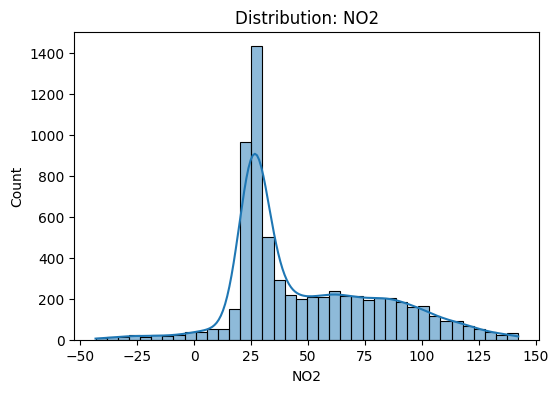

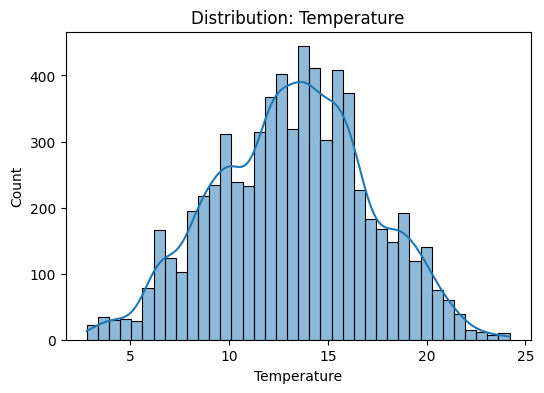

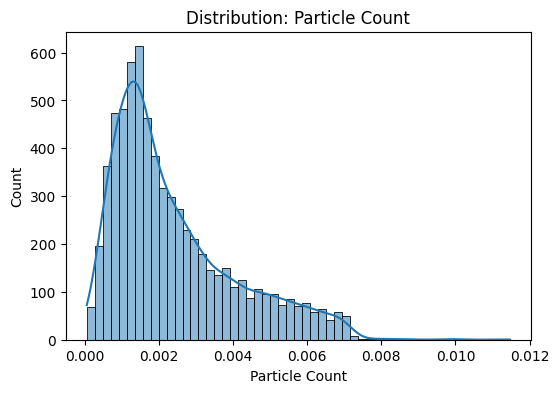

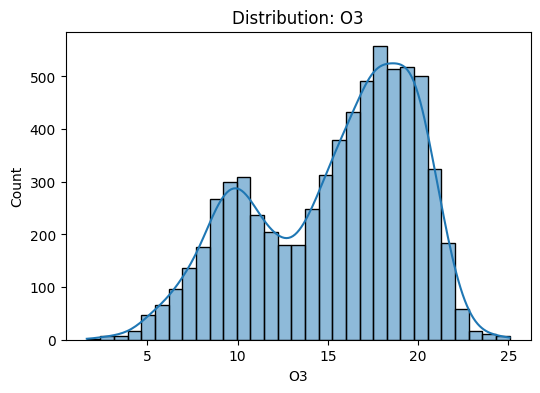

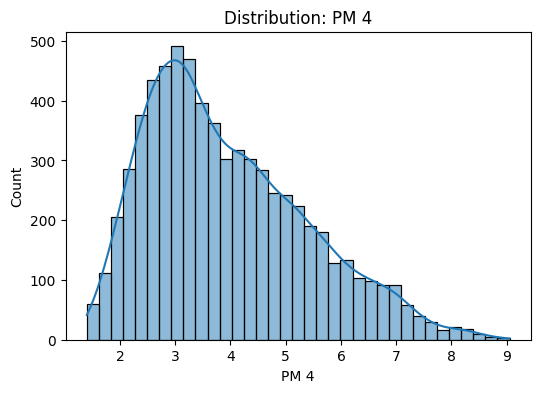

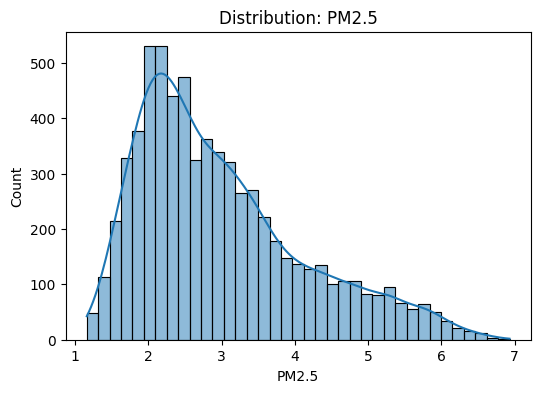

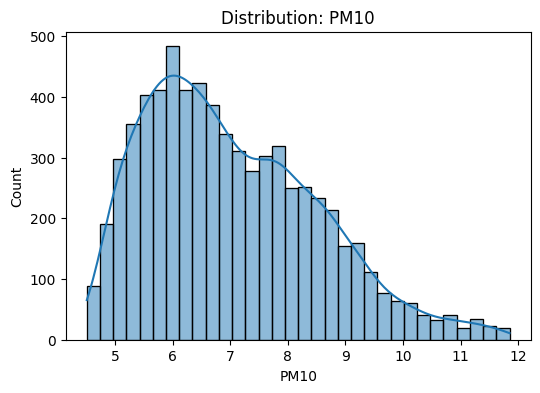

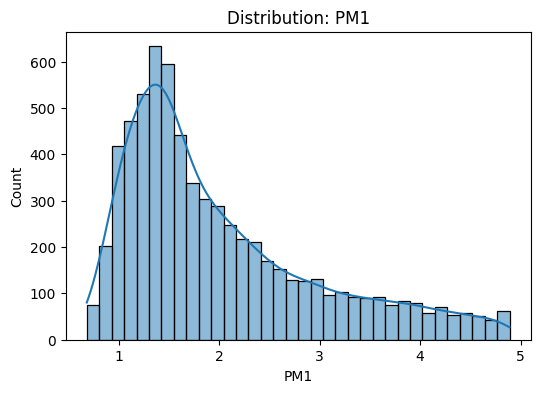

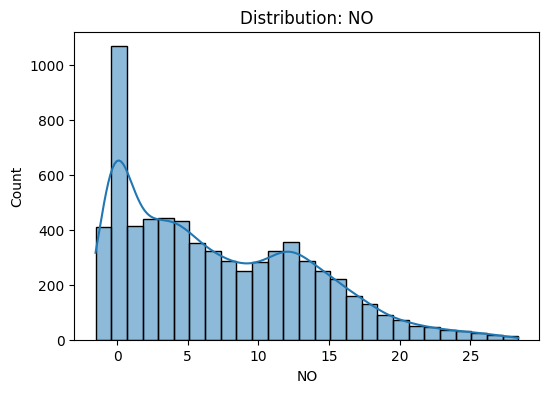

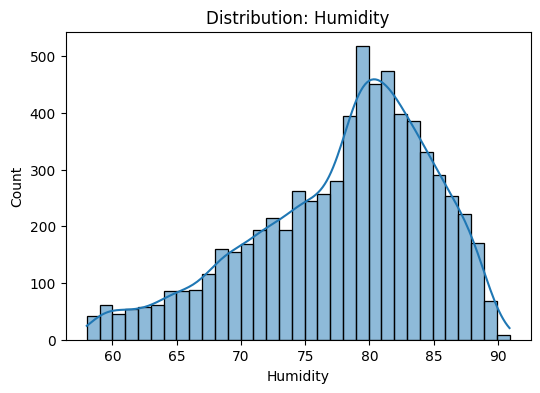

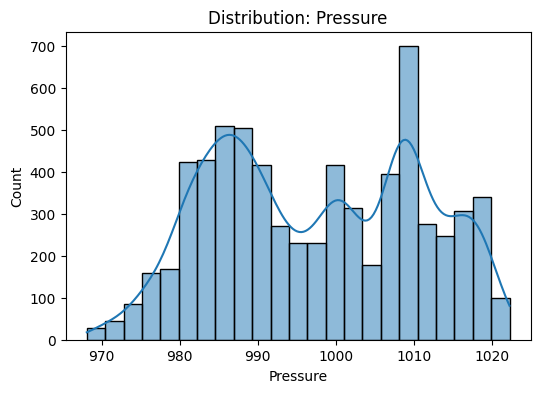

In [16]:
def explore_data(df):
    print("\nBasic Info:\n")
    print(df.info())

    print("\nMissing Values:\n")
    print(df.isna().sum().sort_values(ascending=False))

    print("\nStatistical Summary:\n")
    print(df.describe())

    # Plot distribution of key variables
    to_plot = ["NO2", "Temperature", "Particle Count", "O3", "PM 4", "PM2.5", "PM10", "PM1", "NO", "Humidity", "Pressure"]
    for col in to_plot:
        if col in df.columns:
            plt.figure(figsize=(6,4))
            sns.histplot(df[col], kde=True)
            plt.title(f"Distribution: {col}")
            plt.show()


explore_data(removeoutlier_sensor_data_df)

In [17]:
# 4. FEATURE ENGINEERING
def add_time_features(df):
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["hour"] = df["Timestamp"].dt.hour
    df["day"] = df["Timestamp"].dt.day
    df["weekday"] = df["Timestamp"].dt.weekday
    df["month"] = df["Timestamp"].dt.month
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
    return df

def add_lag_features(df, cols, lags=[1, 3, 6]):
    for col in cols:
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    return df

def add_rolling_features(df, cols, windows=[3, 6]):
    for col in cols:
        for w in windows:
            df[f"{col}_roll_{w}"] = df[col].rolling(w).mean()
    return df

time_features_df = add_time_features(removeoutlier_sensor_data_df)
#lag_features_df = add_lag_features(time_features_df, ["Journey Time", "Plates In", "Plates Matching", "Plates Out"])
#rolling_features = add_rolling_features(lag_features_df, ["Journey Time", "Plates In", "Plates Matching", "Plates Out"])

In [26]:
dropna = time_features_df.dropna()

display(HTML(dropna.head(10).to_html()))

Variable,Timestamp,Humidity,Journey Time,NO,NO2,O3,PM 4,PM1,PM10,PM2.5,Particle Count,Plates In,Plates Matching,Plates Out,Pressure,Temperature,hour,day,weekday,month,is_weekend
0,2025-08-07 23:30:00,74.3,103.5,7.75625,30.56504,10.075,3.84,2.07,6.69,3.05,0.00240,11.5,1.5,11.5,998.7,15.5,23,7,3,8,0
14,2025-08-08 00:30:00,78.6,103.5,6.96875,30.28304,8.180,3.39,1.64,6.68,2.55,0.00175,4.5,0.5,4.0,999.0,15.1,0,8,4,8,0
26,2025-08-08 01:30:00,79.5,97.5,12.11875,27.61344,8.507,3.22,1.51,6.35,2.40,0.00154,4.5,1.0,2.5,999.9,14.0,1,8,4,8,0
39,2025-08-08 02:30:00,79.0,97.5,11.49375,25.47024,10.319,3.52,1.47,7.06,2.46,0.00152,3.0,0.5,3.0,999.7,12.9,2,8,4,8,0
53,2025-08-08 03:30:00,79.8,99.0,13.94375,22.96984,9.908,3.50,1.66,6.75,2.55,0.00184,3.0,0.5,3.5,999.5,12.4,3,8,4,8,0
65,2025-08-08 04:30:00,80.7,97.5,14.19375,22.70664,9.236,3.51,1.64,6.61,2.55,0.00178,4.5,1.0,4.0,999.7,11.9,4,8,4,8,0
77,2025-08-08 05:30:00,79.4,97.5,15.16875,23.96624,10.003,3.36,1.52,6.78,2.44,0.00157,4.5,1.5,4.0,1000.3,12.1,5,8,4,8,0
90,2025-08-08 06:30:00,71.6,127.0,17.71875,26.42904,14.510,3.35,1.40,6.47,2.38,0.00136,18.0,5.0,10.0,1000.8,14.9,6,8,4,8,0
103,2025-08-08 07:30:00,65.4,181.0,10.73125,22.85704,16.928,2.92,1.26,6.01,2.10,0.00111,59.5,8.5,25.5,1000.8,17.1,7,8,4,8,0
115,2025-08-08 08:30:00,61.2,196.5,6.61875,21.12744,18.673,2.53,1.18,5.60,1.93,0.00094,54.0,10.5,27.5,1001.3,18.1,8,8,4,8,0


In [28]:
def generate_congestion(df):
    # Required columns
    required = {"Journey Time", "Plates In", "Plates Out", "Plates Matching"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required variables: {missing}")

    # Work on a copy just for safety
    tmp = df.copy()

    # Traffic volume (temporary)
    traffic_volume = (
        tmp["Plates In"] + tmp["Plates Out"] + tmp["Plates Matching"]
    )

    # --- Journey Time Normalisation ---
    JT_free = tmp["Journey Time"].quantile(0.10)
    JT_worst = tmp["Journey Time"].quantile(0.95)
    jt_norm = (tmp["Journey Time"] - JT_free) / (JT_worst - JT_free)
    jt_norm = jt_norm.clip(0, 1)

    # --- Volume Normalisation ---
    VOL_high = traffic_volume.quantile(0.90)
    vol_norm = (traffic_volume / VOL_high).clip(0, 1)

    # --- Hybrid Congestion Metric ---
    congestion = 100 * (0.6 * jt_norm + 0.4 * vol_norm)

    # return just the series
    return congestion


In [29]:
dropna2 = dropna.copy()

In [30]:
dropna2["Congestion"] = generate_congestion(dropna2)

dropna2 = dropna2.drop(columns=["jt_norm", "vol_norm", "traffic_volume","Plates In", "Plates Matching","Journey Time", "Plates Out"], errors="ignore")

dropna2.head()

Variable,Timestamp,Humidity,NO,NO2,O3,PM 4,PM1,PM10,PM2.5,Particle Count,Pressure,Temperature,hour,day,weekday,month,is_weekend,Congestion
0,2025-08-07 23:30:00,74.3,7.75625,30.56504,10.075,3.84,2.07,6.69,3.05,0.00240,998.7,15.5,23,7,3,8,0,10.205128
14,2025-08-08 00:30:00,78.6,6.96875,30.28304,8.180,3.39,1.64,6.68,2.55,0.00175,999.0,15.1,0,8,4,8,0,5.435897
26,2025-08-08 01:30:00,79.5,12.11875,27.61344,8.507,3.22,1.51,6.35,2.40,0.00154,999.9,14.0,1,8,4,8,0,2.461538
39,2025-08-08 02:30:00,79.0,11.49375,25.47024,10.319,3.52,1.47,7.06,2.46,0.00152,999.7,12.9,2,8,4,8,0,2.000000
53,2025-08-08 03:30:00,79.8,13.94375,22.96984,9.908,3.50,1.66,6.75,2.55,0.00184,999.5,12.4,3,8,4,8,0,2.820513


In [31]:
# ---------------------------------------------------------
# 2. Final DF
# ---------------------------------------------------------
df = dropna2

In [40]:
# ---------------------------------------------------------
# 2. SELECT NUMERIC FEATURES ONLY (XGBoost requirement)
# ---------------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number]).copy()

# Remove label from feature set
X = numeric_df.drop(columns=["Particle Count"])
y = numeric_df["Particle Count"]*1000

y.head()


0     2.40
14    1.75
26    1.54
39    1.52
53    1.84
Name: Particle Count, dtype: float64

In [41]:
# ---------------------------------------------------------
# 3. TRAIN/TEST SPLIT
# ---------------------------------------------------------
# First: train vs test (as you already do)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=False      # keep time order
)

# Second: split TRAIN into (train, val)
val_size = 0.2  # 20% of the *training* data for validation
n_train = int(len(X_train_full) * (1 - val_size))

X_train = X_train_full.iloc[:n_train]
y_train = y_train_full.iloc[:n_train]

X_val   = X_train_full.iloc[n_train:]
y_val   = y_train_full.iloc[n_train:]

In [42]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    eval_metric="rmse",                # moved into constructor
    early_stopping_rounds=50,          # moved into constructor
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'rmse'


In [43]:
y_pred_test = model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("Test RMSE:", rmse_test)
print("Test R²:", r2_test)
print("Best iteration:", model.best_iteration)

Test RMSE: 0.23677111419131122
Test R²: 0.978207709190263
Best iteration: 82


In [48]:
for actual, pred in zip(y_test, y_pred_test):
    print(f"Actual: {actual/1000:.5f}  |  Predicted: {pred/1000:.5f}")

Actual: 0.00153  |  Predicted: 0.00159
Actual: 0.00124  |  Predicted: 0.00128
Actual: 0.00140  |  Predicted: 0.00148
Actual: 0.00185  |  Predicted: 0.00192
Actual: 0.00352  |  Predicted: 0.00275
Actual: 0.00229  |  Predicted: 0.00162
Actual: 0.00083  |  Predicted: 0.00087
Actual: 0.00100  |  Predicted: 0.00105
Actual: 0.00106  |  Predicted: 0.00112
Actual: 0.00454  |  Predicted: 0.00449
Actual: 0.00436  |  Predicted: 0.00438
Actual: 0.00605  |  Predicted: 0.00634
Actual: 0.00462  |  Predicted: 0.00454
Actual: 0.00404  |  Predicted: 0.00389
Actual: 0.00469  |  Predicted: 0.00472
Actual: 0.00330  |  Predicted: 0.00334
Actual: 0.00332  |  Predicted: 0.00334
Actual: 0.00252  |  Predicted: 0.00248
Actual: 0.00266  |  Predicted: 0.00265
Actual: 0.00113  |  Predicted: 0.00116
Actual: 0.00191  |  Predicted: 0.00190
Actual: 0.00347  |  Predicted: 0.00326
Actual: 0.00326  |  Predicted: 0.00318
Actual: 0.00276  |  Predicted: 0.00272
Actual: 0.00177  |  Predicted: 0.00177
Actual: 0.00079  |  Predi